In [3]:
from lbg_forecast.likelihood import Likelihood
import lbg_forecast.utils as utils

from lbg_forecast.angular_power import pk
import lbg_forecast.angular_power as ap

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax_cosmo as jc
import jax
from jax import jacfwd
from jax import jit

from uncertainties import unumpy as upy

In [4]:
def trig_plot(nparams, params, F, F_marg, F_extra=None, labels=None, colour='r', colour_extra='purple', fill=True, lw=2, alpha=0.3, alpha_step=1.0, points=None, points2=None):
    
    plt.figure(figsize=(25, 30))

    #randnos = np.random.multivariate_normal(np.array([params[0], params[1]]),
    #                                         np.linalg.inv(F), 1000)
    for i in range(nparams):
        for j in range(nparams):
            if j<i:
                plt.subplot(nparams,nparams,i*nparams+j+1)
                plt.subplots_adjust(wspace=0, hspace=0)

                plt.grid(alpha=0.4, zorder=-1)

                utils.plot_contours(F, params, j, i, K=2.279, fill=fill,color='k', alpha=alpha, zorder=5, ls="--", lw=lw)
                utils.plot_contours(F, params, j, i, K=5.991, fill=fill,color='k',  alpha=alpha*alpha_step, zorder=5, ls="--", lw=lw)
                #plot_contours(F, params, j, i, K=9.210, fill=True,color='k',  alpha=0.3, zorder=5, ls="--", lw=2)
                    #plot_contours(F, params, j, i, K=11.618, fill=True,color='b',  alpha=0.3, zorder=5)

                utils.plot_contours(F_marg, params, j, i, K=2.279, fill=fill,color=colour, alpha=alpha, zorder=1, lw=lw)
                utils.plot_contours(F_marg, params, j, i, K=5.991, fill=fill,color=colour, alpha=alpha*alpha_step, zorder=1, lw=lw)
                    #plot_contours(F_marg, params, j, i, K=9.210, fill=True,color='r',  alpha=0.3, zorder=1)
                    #plot_contours(F_marg, params, j, i, K=11.618, fill=True,color='r', alpha=0.3, zorder=1)

                if(F_extra is not None):
                    utils.plot_contours(F_extra, params, j, i, K=2.279, fill=fill,color=colour_extra, alpha=alpha, zorder=1, lw=lw, ls='-.')
                    utils.plot_contours(F_extra, params, j, i, K=5.991, fill=fill,color=colour_extra, alpha=alpha*alpha_step, zorder=1, lw=lw, ls='-.')

                if points is not None:
                    plt.scatter(points[j], points[i], marker='x', s=200, color='purple')
                if points2 is not None:
                    plt.scatter(points2[j], points2[i], marker='o', s=80, color='k')
                
                if(j == 0):
                    plt.ylabel(labels[i], fontsize = 32)

                if(i == nparams-1):
                    plt.xlabel(labels[j], fontsize = 32)

                plt.tick_params(axis="x", width = 2, labelsize=15)
                plt.tick_params(axis="y", width = 2, labelsize=15)

                if(i < nparams - 1):
                    plt.tick_params(
                        axis='x',          # changes apply to the x-axis
                        which='both',      # both major and minor ticks are affected
                        bottom=False,      # ticks along the bottom edge are off
                        labelbottom=False)
                    
                if(j > 0):
                    plt.tick_params(
                        axis='y',          # changes apply to the x-axis
                        which='both',      # both major and minor ticks are affected
                        left=False,        # ticks along the bottom edge are off
                        labelleft=False)
                #plt.scatter(randnos[:,0], randnos[:, 1], c ='r', zorder=100, alpha=.5, s=10)

In [5]:
path = "./"
lhood = Likelihood(path)
lhood_red = Likelihood(path, n_override='min')
lhood_max = Likelihood(path, n_override='max')

Initialising likelihood
Initialisation Complete
Initialising likelihood
Initialisation Complete
Initialising likelihood
Initialisation Complete


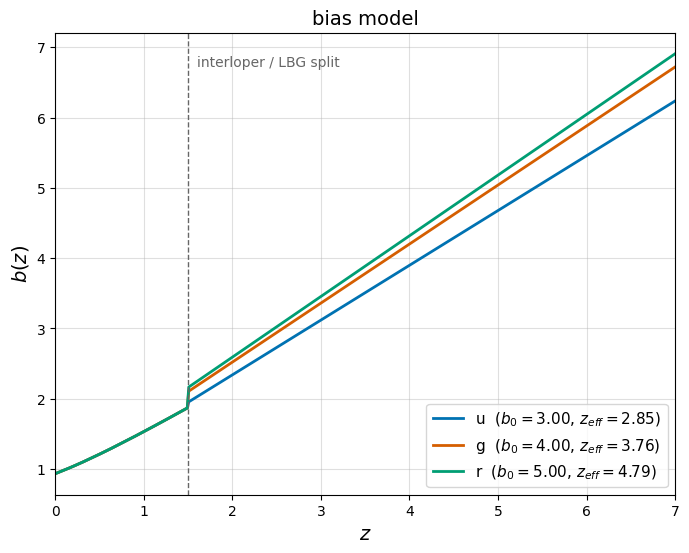

In [6]:
# b(z) for the bias model, with everything adjustable. growth_bias_I is the same
# class the forecast uses, so this plot cannot drift from the actual model.
from lbg_forecast.modified_bias import growth_bias_I

# ---- adjust ---------------------------------------------------------------
b_0s    = [lhood._b_lbg_u, lhood._b_lbg_g, lhood._b_lbg_r]  # LBG bias at z_eff
z_effs  = [lhood._z_eff_u, lhood._z_eff_g, lhood._z_eff_r]  # pivot redshift per sample
b_I     = lhood._b_I         # interloper amplitude; interloper bias is b_I/D(z)
z_range = (0.0, 7.0)         # x limits
y_range = None               # y limits, e.g. (0, 8); None autoscales
# ---------------------------------------------------------------------------

names   = ["u", "g", "r"]
colours = ["#0072B2", "#D55E00", "#009E73"]   # Okabe-Ito, colourblind safe

z = jnp.linspace(z_range[0], z_range[1], 400)

plt.figure(figsize=(8, 6))
for name, b_0, z_e, c in zip(names, b_0s, z_effs, colours):
    b = growth_bias_I(b_0, b_I, z_e)
    plt.plot(z, b(lhood._cosmo_fid, z), color=c, lw=2,
             label="%s  ($b_{0}=%.2f$, $z_{eff}=%.2f$)" % (name, b_0, z_e))

plt.xlim(z_range)
if y_range is not None:
    plt.ylim(y_range)

# z = 1.5 is where the model switches from interlopers to LBGs
plt.axvline(1.5, color="0.4", ls="--", lw=1)
plt.text(1.6, plt.ylim()[0] + 0.95*(plt.ylim()[1] - plt.ylim()[0]),
         "interloper / LBG split", fontsize=10, color="0.4", va="top")

plt.xlabel("$z$", fontsize=14)
plt.ylabel("$b(z)$", fontsize=14)
plt.title("bias model", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.4)


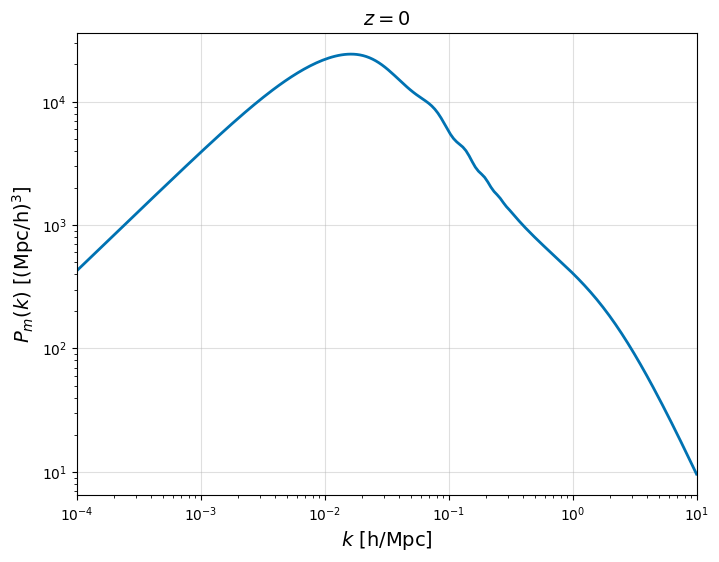

In [7]:
# nonlinear matter power spectrum at z=0 for the fiducial cosmology (no bias)
# ---- adjust ---------------------------------------------------------------
k_range = (-4, 1)     # log10 k limits [h/Mpc]
nk      = 200
z_m     = 0.0         # redshift
y_range = None        # y limits, e.g. (1e0, 1e5); None autoscales
# ---------------------------------------------------------------------------
k = jnp.logspace(k_range[0], k_range[1], nk)

plt.figure(figsize=(8, 6))
plt.plot(k, pk(lhood._cosmo_fid, k, z_m), color="#0072B2", lw=2)
plt.xscale("log")
plt.yscale("log")
plt.xlim(10.0**k_range[0], 10.0**k_range[1])
if y_range is not None:
    plt.ylim(y_range)
plt.xlabel("$k$ [h/Mpc]", fontsize=14)
plt.ylabel("$P_{m}(k)$ [(Mpc/h)$^3$]", fontsize=14)
plt.title("$z=%g$" % z_m, fontsize=14)
plt.grid(alpha=0.4)


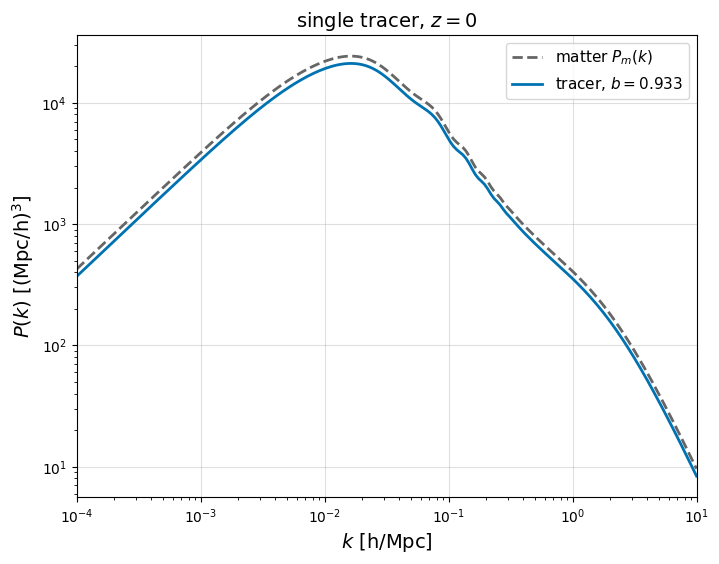

In [8]:
# Single-tracer power spectrum at the same redshift as the matter P(k) above,
# using a bias you define here. my_bias uses the same interface as the models in
# lbg_forecast.modified_bias, so the same object feeds straight into the kernel:
#     modified_probes.NumberCounts([nz], [bias_obj], f_NL)
import jax_cosmo.background as bkgrd
from jax.tree_util import register_pytree_node_class
from jax_cosmo.jax_utils import container
from jax_cosmo.utils import z2a
from lbg_forecast import modified_probes

# ---- define your bias here ------------------------------------------------
@register_pytree_node_class
class my_bias(container):
    """b(z) for a single tracer. Edit the body; params come from the constructor.
    z arrives as an array - jax_cosmo's growth_factor rejects scalars."""

    def __call__(self, cosmo, z):
        b_I = self.params[0]
        return b_I / bkgrd.growth_factor(cosmo, z2a(z))

bias_obj = my_bias(lhood._b_I)

# ---- adjust ---------------------------------------------------------------
z_tracer = 0.0            # same redshift as the matter P(k) above
k_range  = (-4, 1)        # log10 k limits [h/Mpc]
nk       = 200
f_NL     = 0.0            # non-zero adds the scale-dependent PNG bias
y_range  = None           # y limits, e.g. (1e0, 1e5); None autoscales
# ---------------------------------------------------------------------------

cosmo = lhood._cosmo_fid
k     = jnp.logspace(k_range[0], k_range[1], nk)
z_arr = jnp.atleast_1d(float(z_tracer))

b_z = bias_obj(cosmo, z_arr)
P_m = pk(cosmo, k, z_tracer)

plt.figure(figsize=(8, 6))
plt.plot(k, P_m, color="0.4", lw=2, ls="--", label="matter $P_{m}(k)$")
plt.plot(k, b_z[0]**2 * P_m, color="#0072B2", lw=2,
         label="tracer, $b=%.3f$" % b_z[0])

if f_NL != 0.0:
    b_k = b_z + modified_probes.png_bias(cosmo, b_z, k, z_arr, f_NL)
    plt.plot(k, jnp.abs(b_k**2 * P_m), color="#D55E00", lw=2,
             label=r"tracer, $f_{NL}=%g$" % f_NL)

plt.xscale("log")
plt.yscale("log")
plt.xlim(10.0**k_range[0], 10.0**k_range[1])
if y_range is not None:
    plt.ylim(y_range)
plt.xlabel("$k$ [h/Mpc]", fontsize=14)
plt.ylabel("$P(k)$ [(Mpc/h)$^3$]", fontsize=14)
plt.title("single tracer, $z=%g$" % z_tracer, fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.4)


u x u: <b b>_eff = 8.872, z_eff = 2.848
u x g: <b b>_eff = 11.197, z_eff = 3.167
u x r: <b b>_eff = 8.846, z_eff = 2.783
u x $\kappa$: <b b>_eff = 2.895, z_eff = 2.755
g x g: <b b>_eff = 15.850, z_eff = 3.762
g x r: <b b>_eff = 21.189, z_eff = 4.414
g x $\kappa$: <b b>_eff = 3.906, z_eff = 3.723
r x r: <b b>_eff = 24.929, z_eff = 4.790
r x $\kappa$: <b b>_eff = 4.993, z_eff = 4.801
$\kappa$ x $\kappa$: <b b>_eff = 1.000, z_eff = 2.292


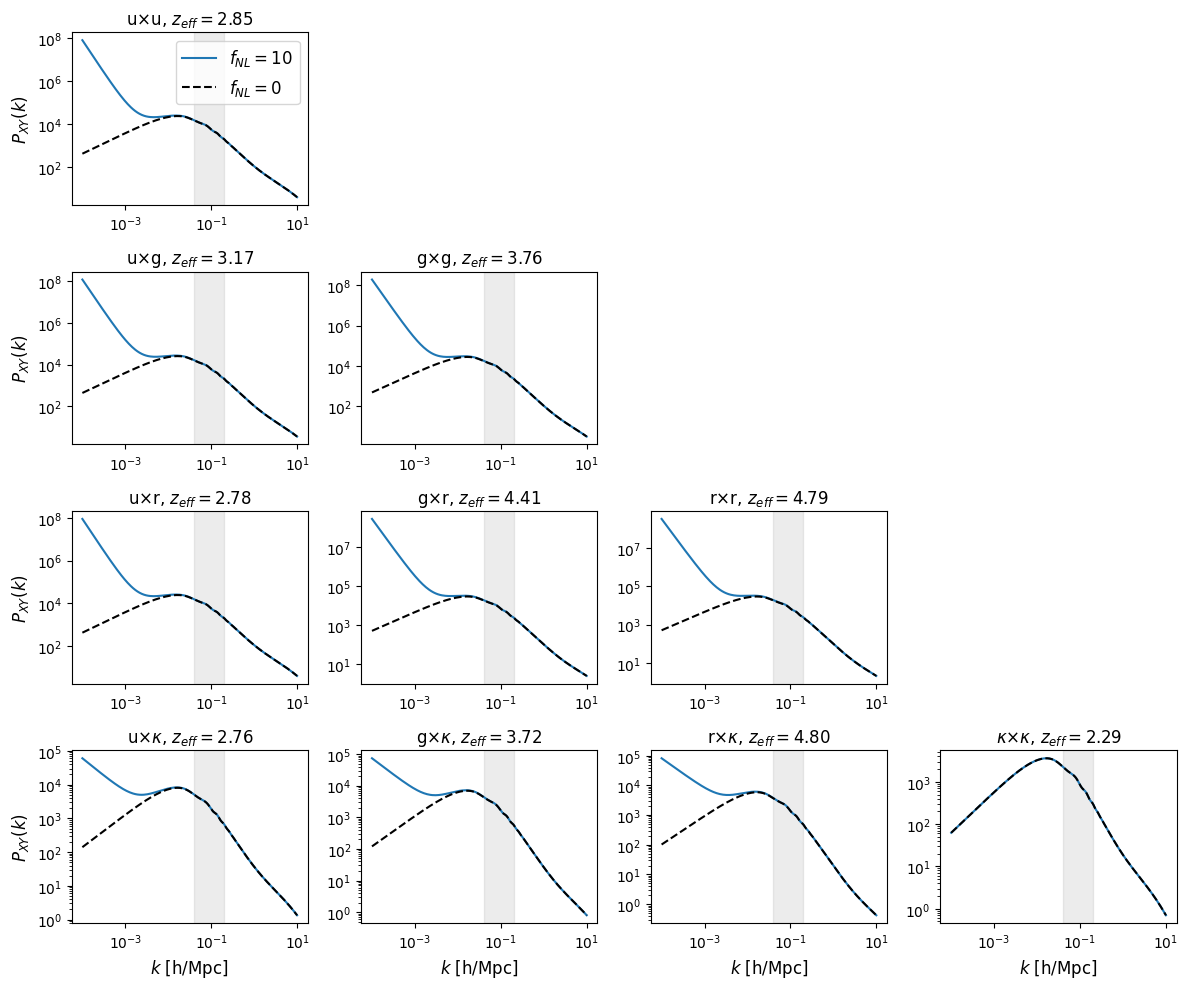

In [9]:
import jax.numpy as jnp
from lbg_forecast.angular_power import plot_tracer_pk

#Plots fiducial tracer power spectrum and effective bias and redshift

fig, axes, b_eff, z_eff = plot_tracer_pk(lhood._cosmo_fid, lhood.nz_params_mean, lhood._bias_params,
                                         jnp.logspace(-4, 1, 200), lhood.ndens, (12, 10), 12, f_NL=10.0)


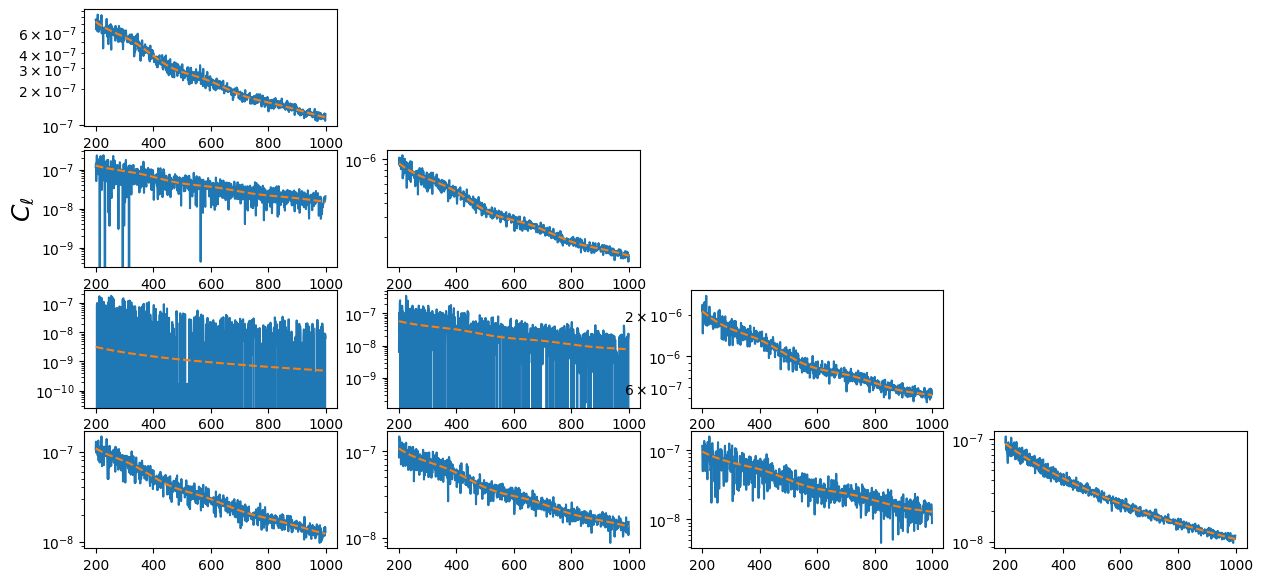

In [8]:
params = np.array([lhood._cosmo_fid.sigma8, 
                lhood._cosmo_fid.Omega_c, lhood._cosmo_fid.Omega_b,
                lhood._cosmo_fid.h, lhood._cosmo_fid.n_s,
                lhood._b_lbg_u, lhood._b_lbg_g, lhood._b_lbg_r,
                lhood._b_I, lhood._f_NL])

params_mod = np.array([lhood._cosmo_fid.sigma8, 
                lhood._cosmo_fid.Omega_c, lhood._cosmo_fid.Omega_b,
                lhood._cosmo_fid.h, lhood._cosmo_fid.n_s,
                lhood._b_lbg_u, lhood._b_lbg_g, lhood._b_lbg_r,
                lhood._b_I, lhood._f_NL])

ap.compare_cls(lhood.cl_mean, lhood.mu_vec(params_mod), lhood._ell, (15, 7), 18, 4)


In [9]:
def forecast_derived():
    o_m = lhood._cosmo_fid.Omega_c + lhood._cosmo_fid.Omega_b
    s8 = lhood._cosmo_fid.sigma8*np.sqrt(o_m/0.3)

    params = np.array([o_m, s8, lhood._cosmo_fid.Omega_b,
                    lhood._cosmo_fid.h, lhood._cosmo_fid.n_s,
                    lhood._b_lbg_u, lhood._b_lbg_g, lhood._b_lbg_r,
                    lhood._b_I, lhood._f_NL])

    labels = np.array(["$\Omega_{m}$", "$S_{8}$","$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$", "$b_{I}$", "$f_{NL}$"])

    F = lhood.fisher_deriv(params)
    F_marg = lhood.fisher_marg_deriv(params)

    return F, F_marg, params, labels


In [10]:
def forecast(lhood, red=1.0):

    params = np.array([lhood._cosmo_fid.sigma8, 
                    lhood._cosmo_fid.Omega_c, lhood._cosmo_fid.Omega_b,
                    lhood._cosmo_fid.h, lhood._cosmo_fid.n_s,
                    lhood._b_lbg_u, lhood._b_lbg_g, lhood._b_lbg_r,
                    lhood._b_I, lhood._f_NL])

    labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$", "$b_{I}$", "$f_{NL}$"])

    F = lhood.fisher(params, red)
    F_marg = lhood.fisher_marg(params, red)

    return F, F_marg, params, labels


def fix_param(F, idx):
    """Fix a parameter at its fiducial value: delete its row/column from the Fisher matrix"""
    return np.delete(np.delete(F, idx, axis=0), idx, axis=1)


def marginalise_param(F, idx):
    """Marginalise over a parameter: delete it from the covariance, then invert back"""
    return np.linalg.inv(fix_param(np.linalg.inv(F), idx))

In [11]:
F_noint, F_noint_marg, params, labels = forecast(lhood, red=0.0)

In [12]:
F, F_marg, params, labels = forecast(lhood)
#np.save('fisher_data/fisher.npy', F)
#np.save('fisher_data/fisher_marg.npy', F_marg)

In [13]:
F_red, F_red_marg, params, labels = forecast(lhood_red)

In [14]:
F_max, F_max_marg, params, labels = forecast(lhood_max)

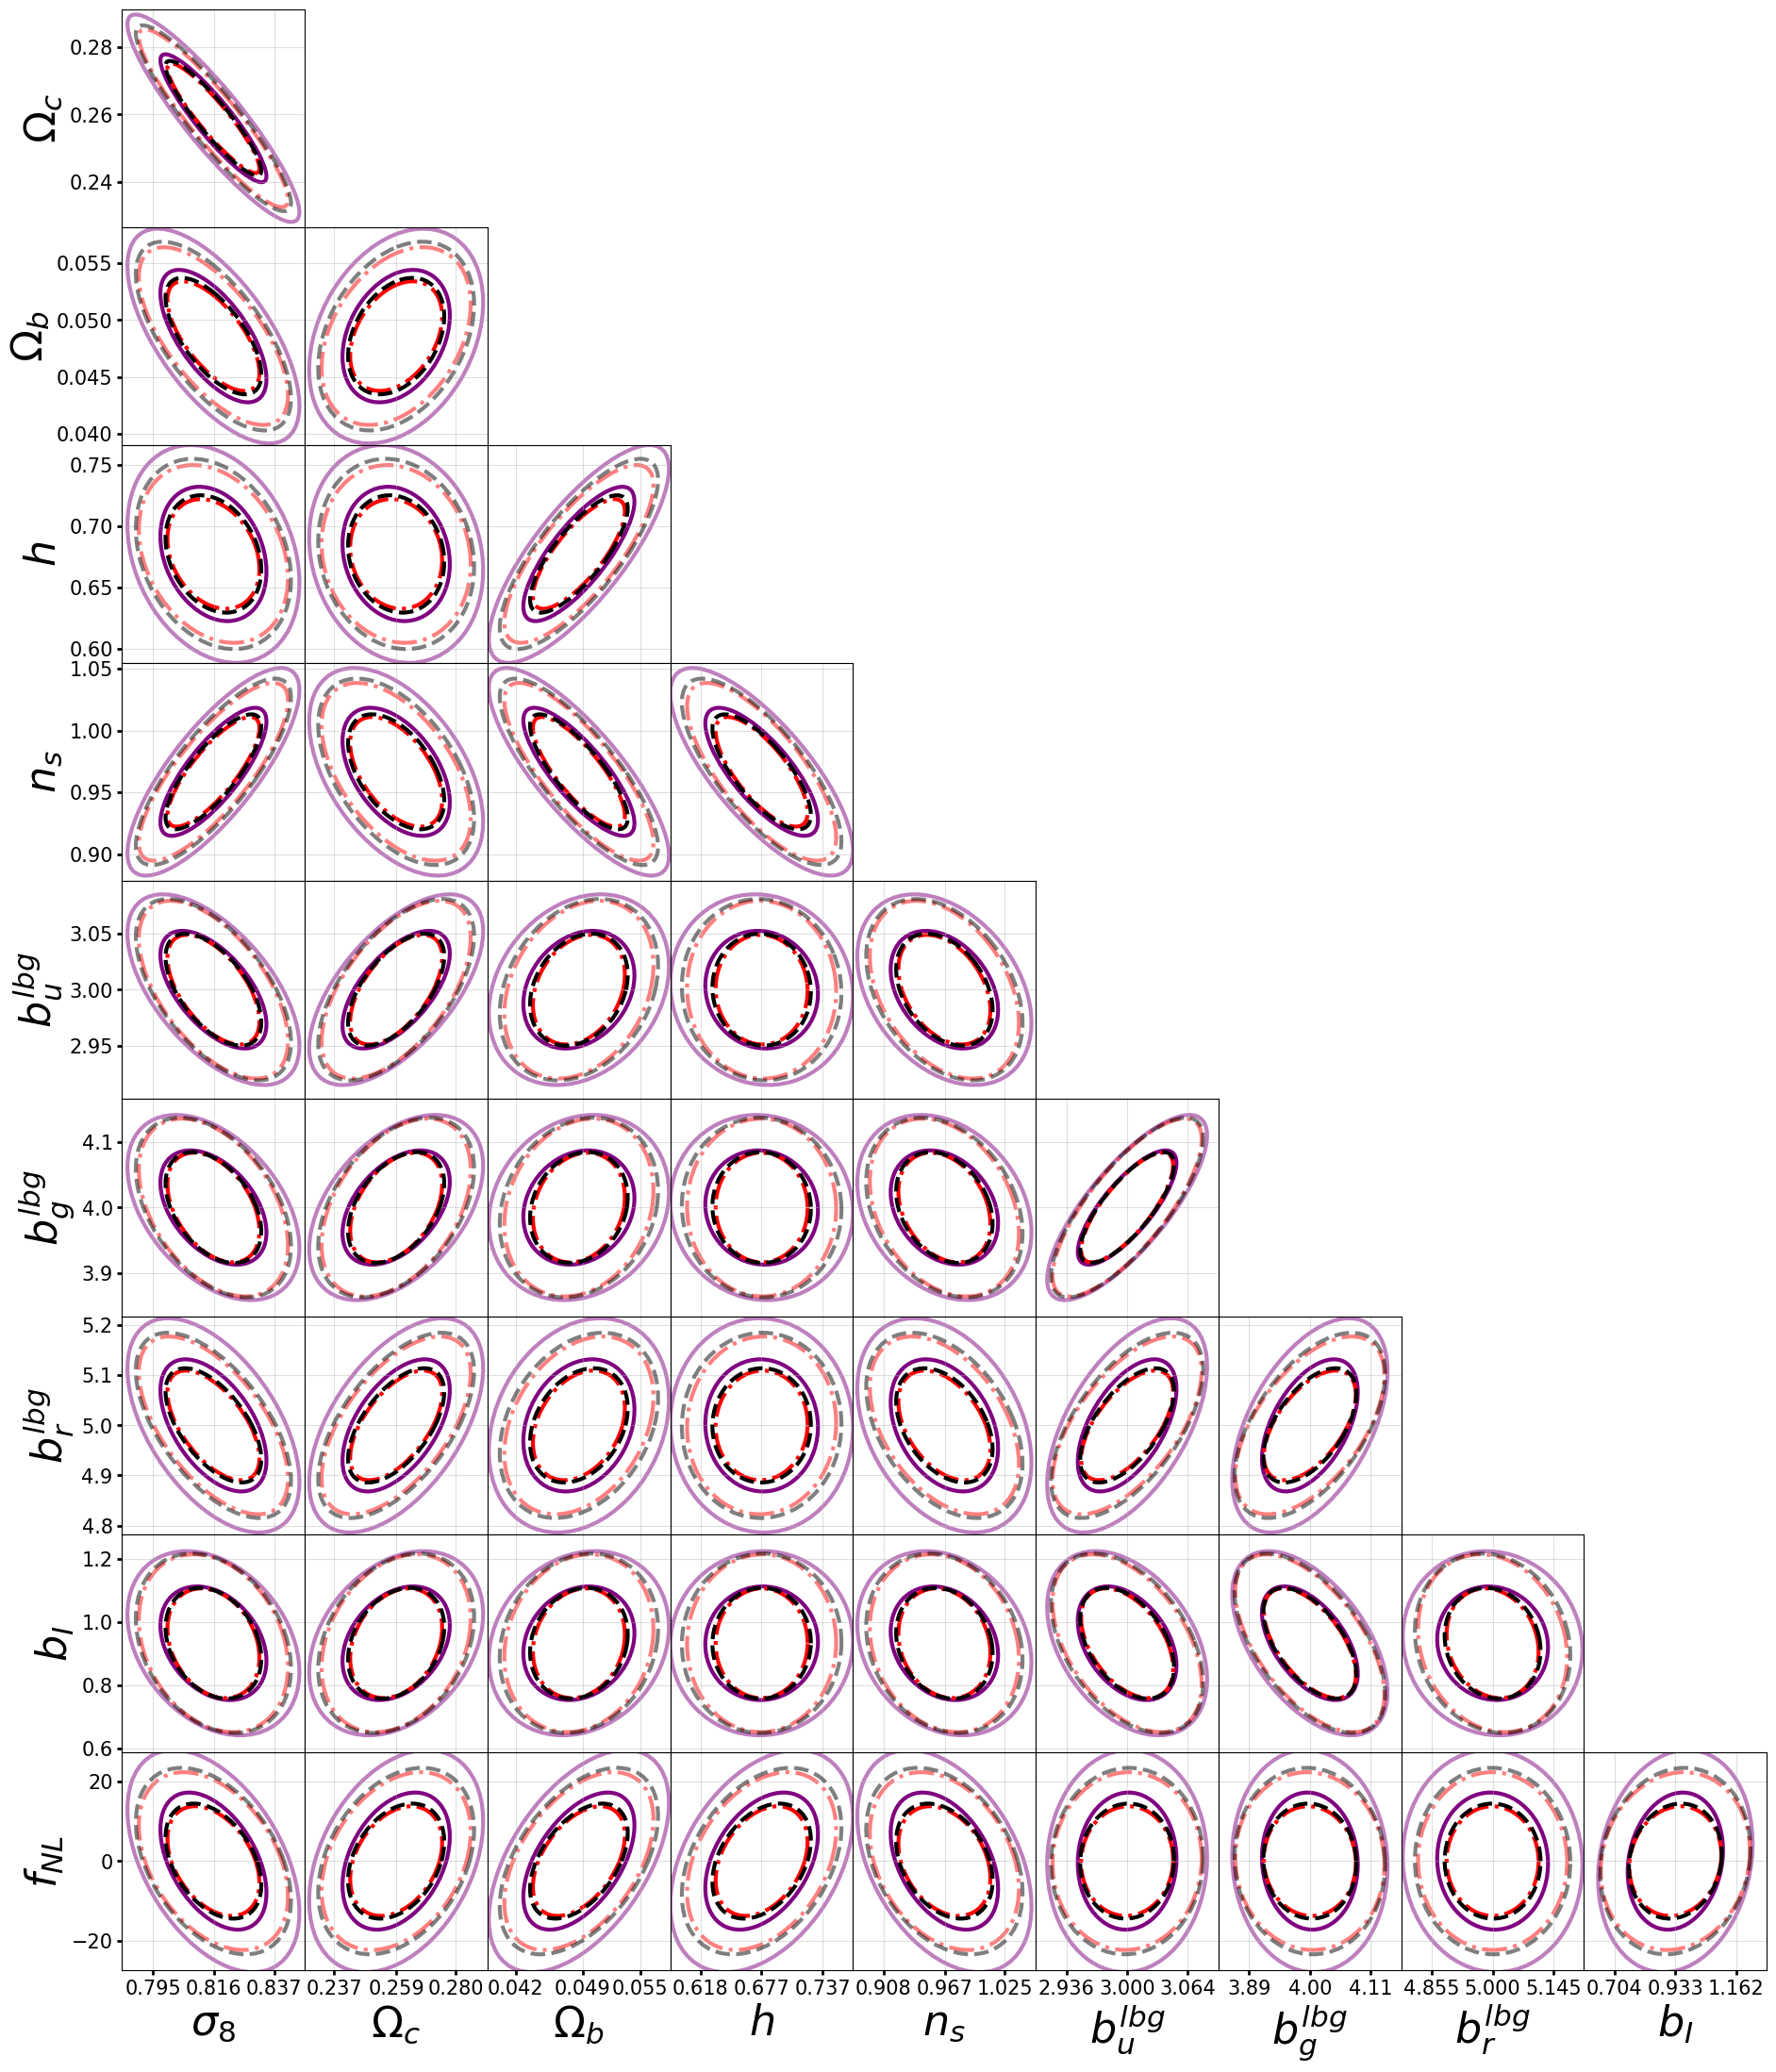

In [15]:
trig_plot(len(params), params, F_marg, F_red_marg, F_max_marg, labels=labels, colour='purple', colour_extra='red', fill=False, lw=3, alpha=1.0, alpha_step=0.5)

In [16]:
np.sqrt(np.linalg.inv(F_marg)[0, 0])/lhood._cosmo_fid.sigma8, np.sqrt(np.linalg.inv(F_max_marg)[0, 0])/lhood._cosmo_fid.sigma8, np.sqrt(np.linalg.inv(F_red_marg)[0, 0])/lhood._cosmo_fid.sigma8

(0.013493555203113353, 0.012965806413651287, 0.014953381013769295)

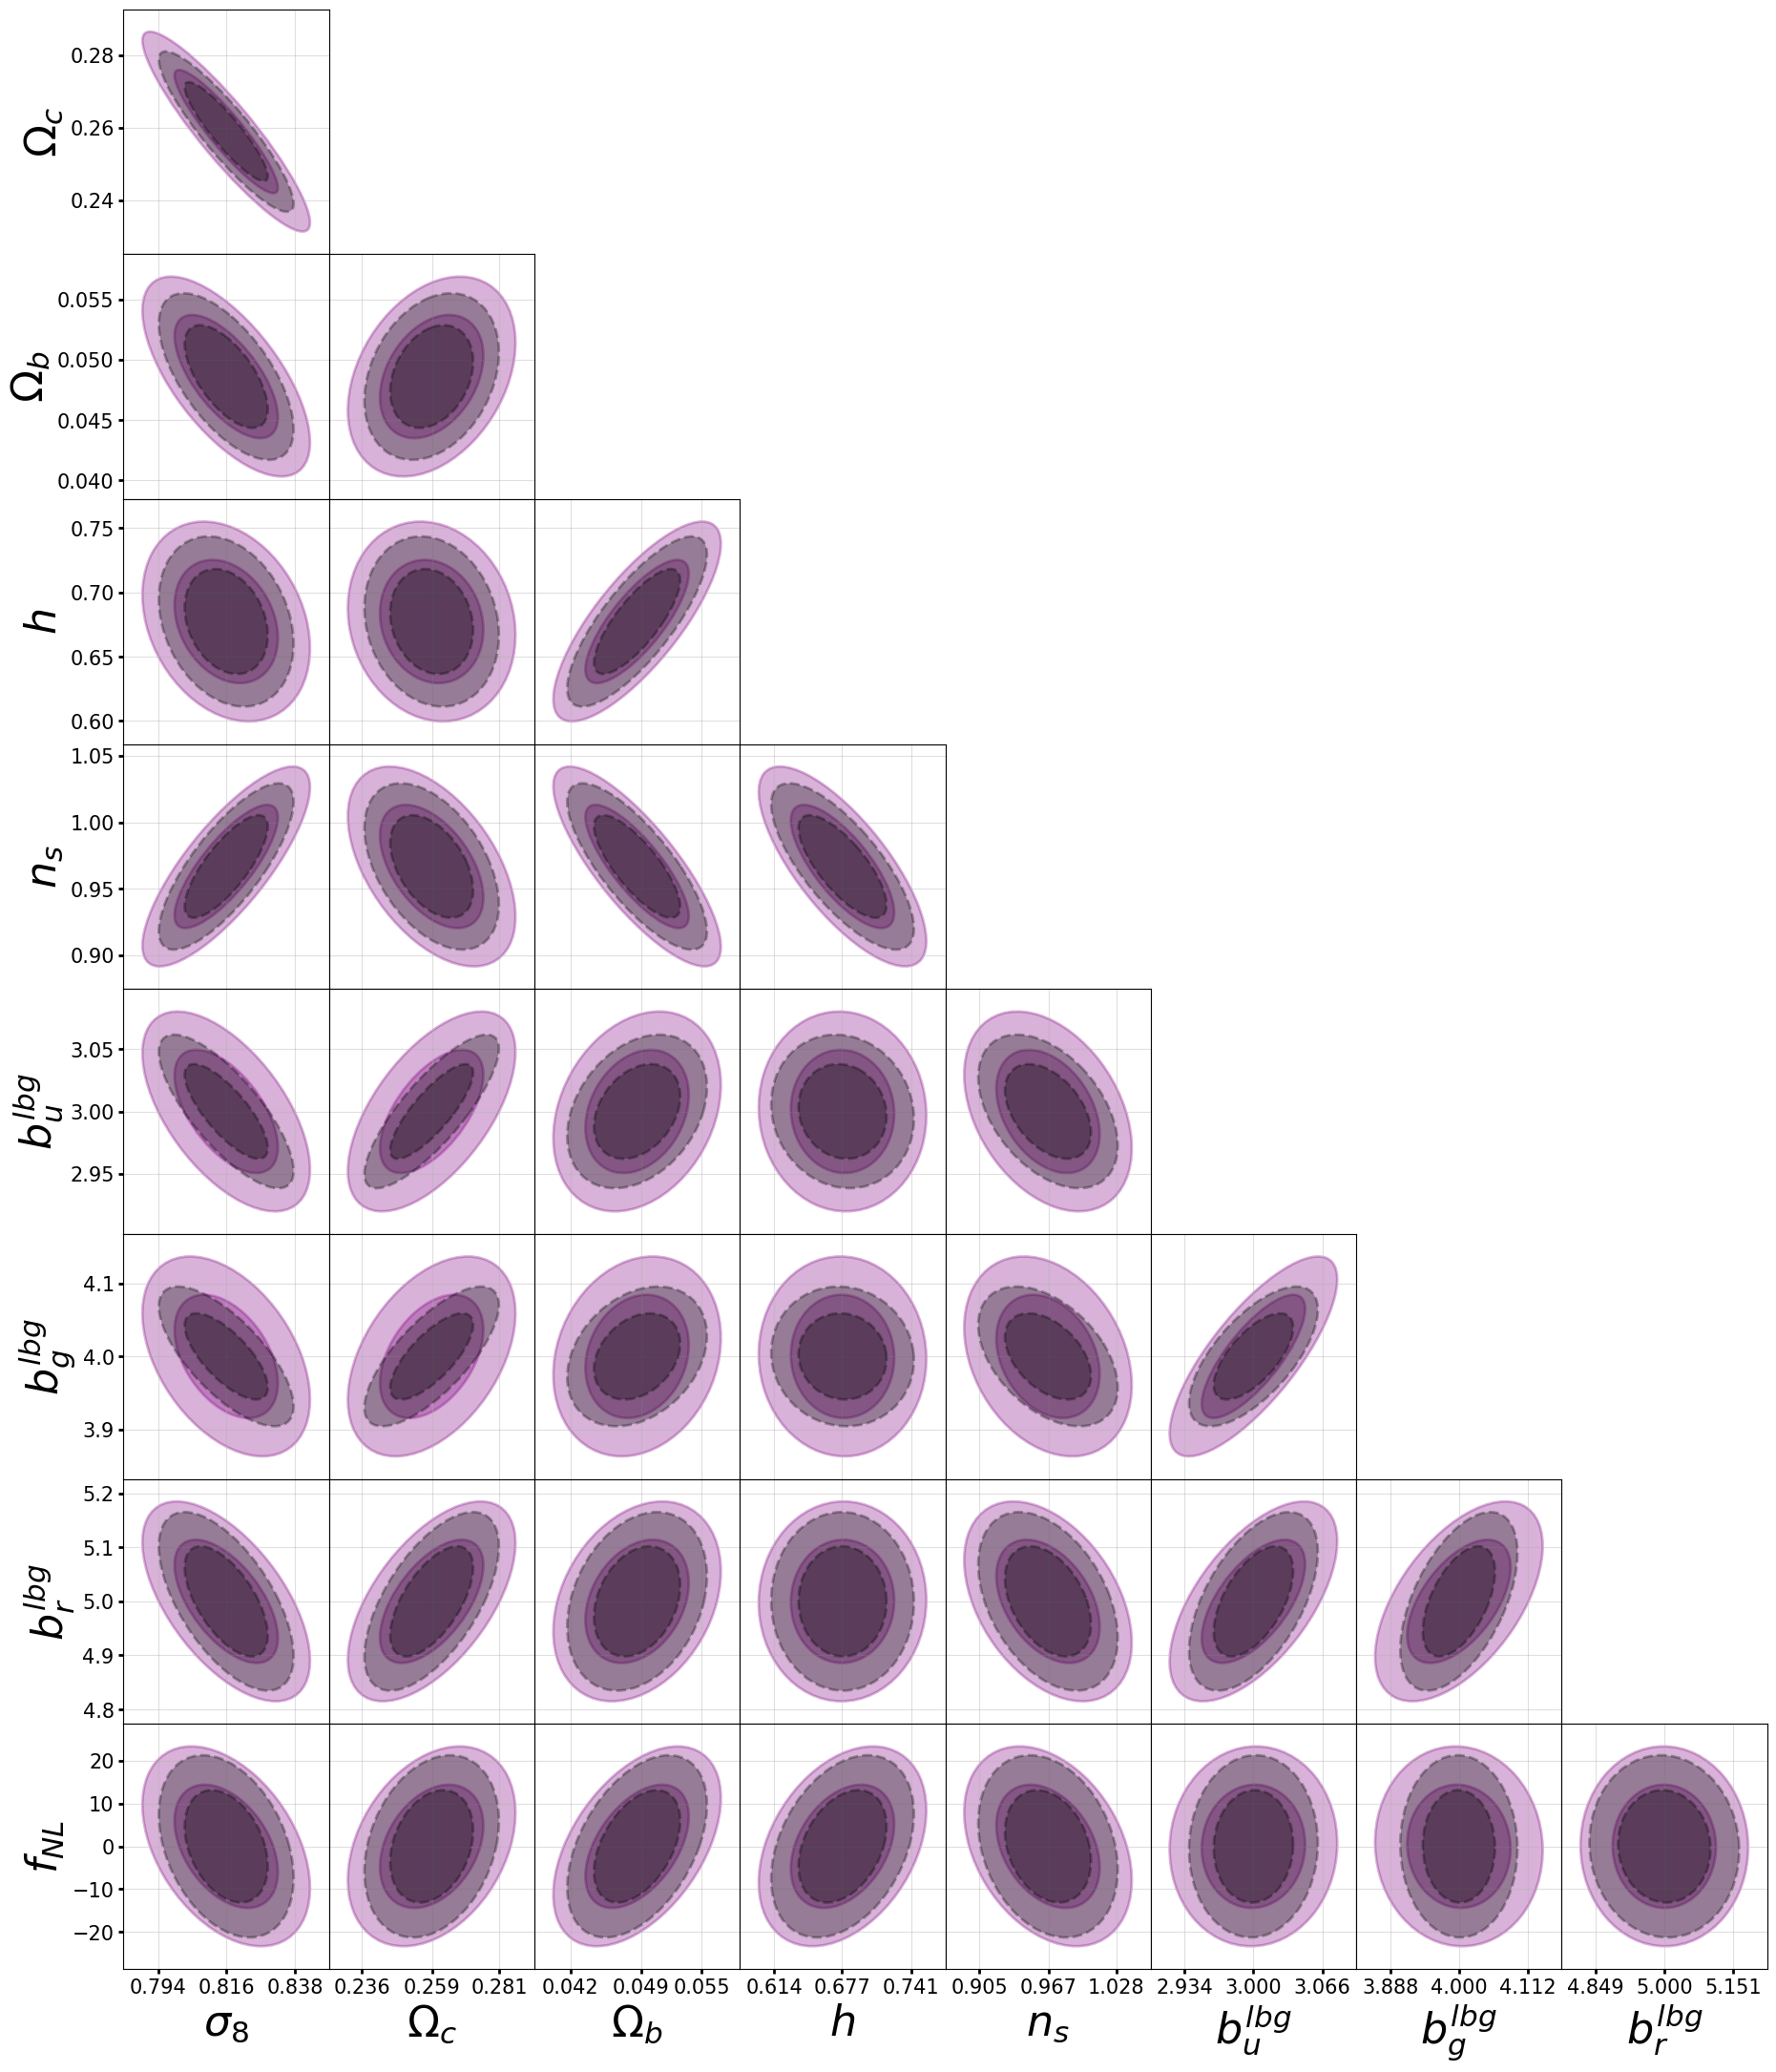

In [17]:
# with no interlopers (red=0) the interloper amplitude b_I has no effect on the cls, so its
# Fisher row/column is zero. Fixing it there is exact; in the interloper forecast it is
# marginalised over instead.
i_b_I = [8]
trig_plot(len(params) - len(i_b_I), np.delete(params, i_b_I),
          fix_param(F_noint_marg, i_b_I), marginalise_param(F_marg, i_b_I),
          F_extra=None, labels=np.delete(labels, i_b_I), colour='purple')

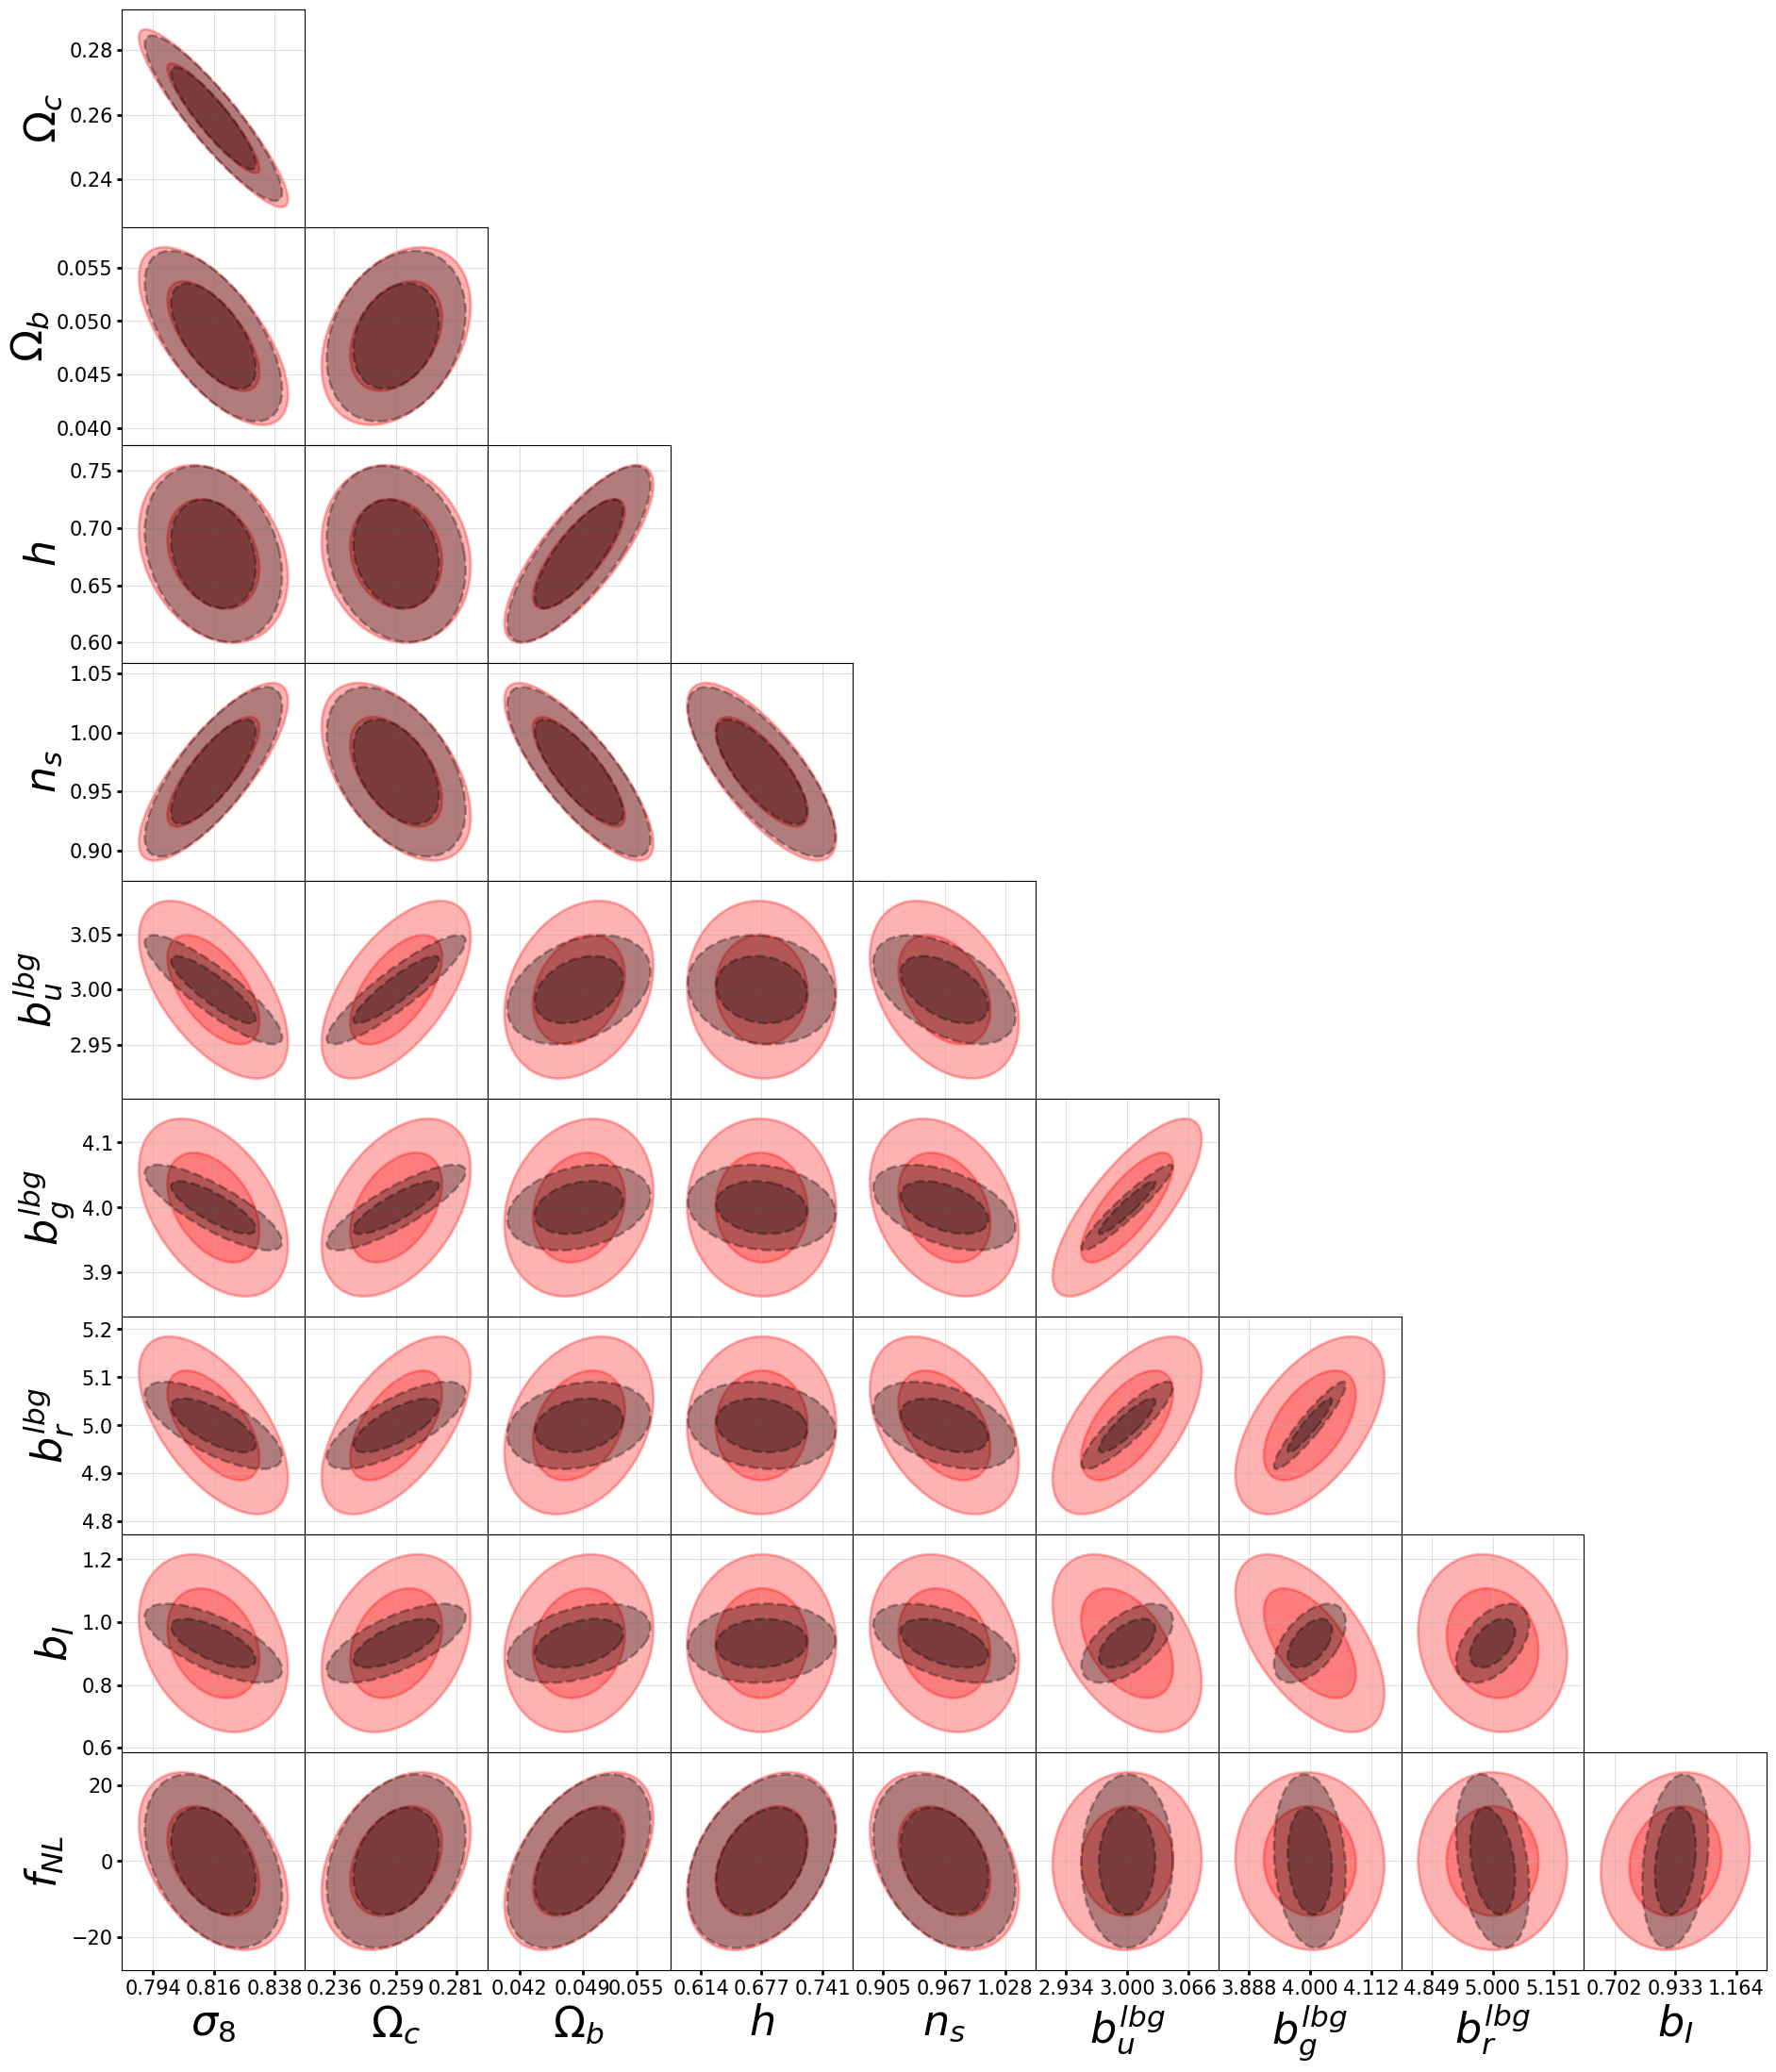

In [18]:
trig_plot(len(params), params, F, F_marg, F_extra=None, labels=labels)

In [19]:
def forecast_biases(lhood, red=1.0):

    # NOTE: results.npy predates the single-b_I reparameterisation;
    # it needs regenerating before this forecast will line up with the 10-param vector
    params = np.append(np.load('biases/results.npy')[-1, :], lhood._f_NL)

    labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$", "$b_{I}$", "$f_{NL}$"])

    F = lhood.fisher(params, red)
    F_marg = lhood.fisher_marg(params, red)

    return F, F_marg, params, labels

In [20]:
#F_b, F_marg_b, params_b, labels = forecast_biases(lhood)

In [21]:
#biases = np.load('biases/results.npy')[0, :]
#init = np.load('biases/results.npy')[-1, :]
#trig_plot(5, params_b, F_b, F_marg_b, F_extra=None, labels=labels, points=biases, points2=init)

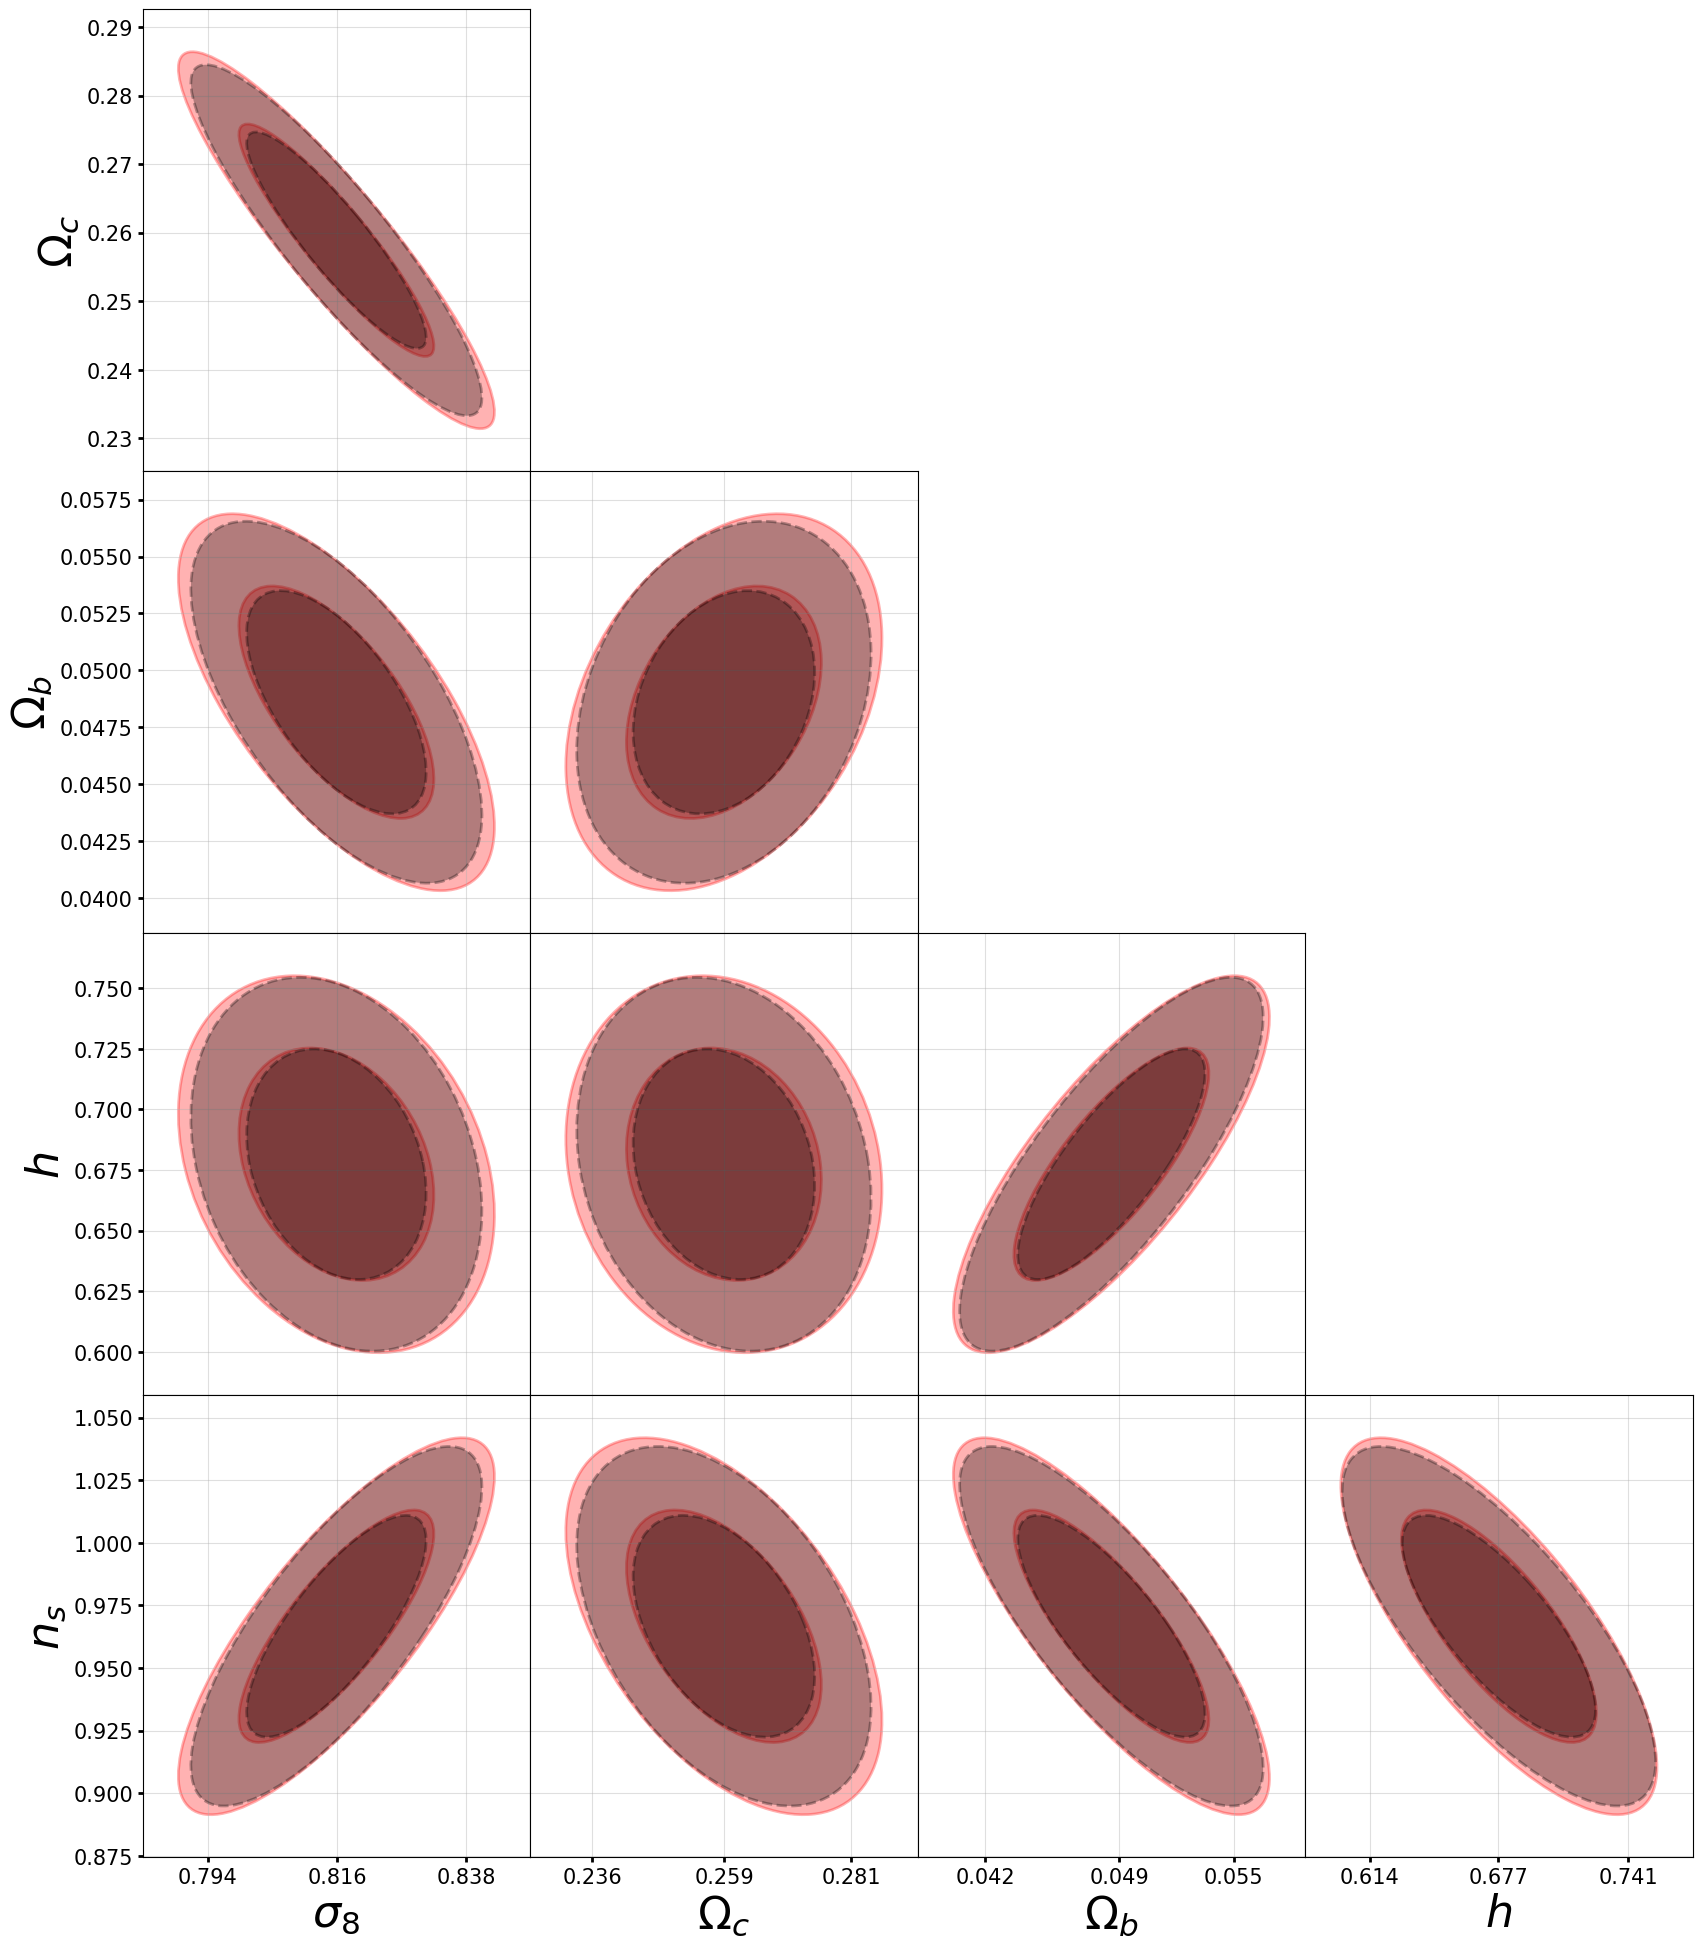

In [22]:
trig_plot(5, params, F, F_marg, F_extra=None, labels=labels)

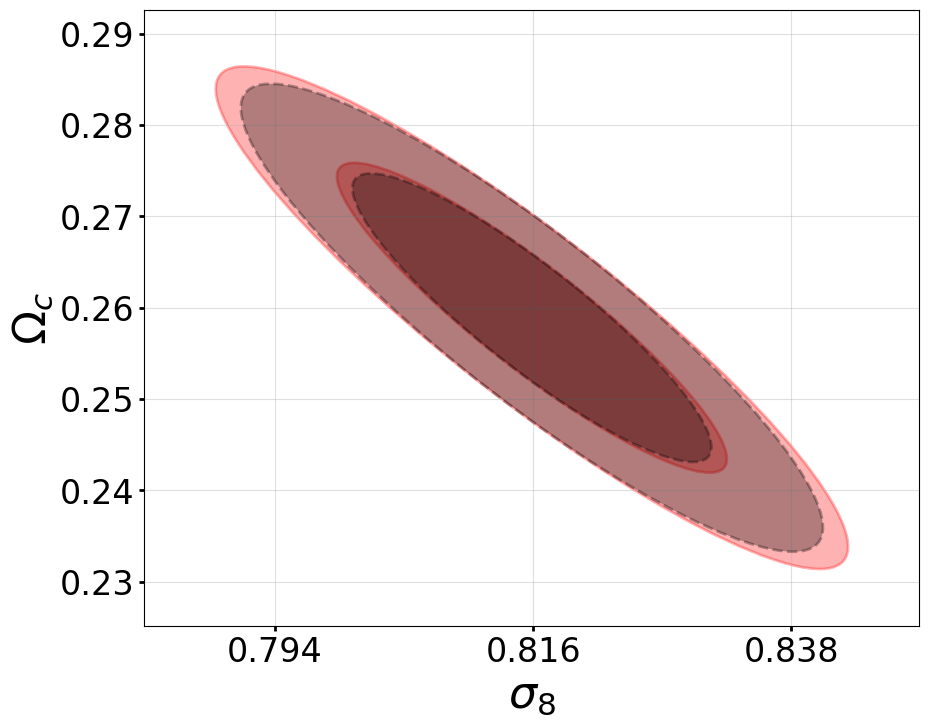

In [23]:
i = 1
j = 0
plt.figure(figsize=(10, 8))
plt.grid(alpha=0.4, zorder=-1)

utils.plot_contours(F, params, j, i, K=2.279, fill=True,color='k', alpha=0.3, zorder=5, ls="--", lw=2)
utils.plot_contours(F, params, j, i, K=5.991, fill=True,color='k',  alpha=0.3, zorder=5, ls="--", lw=2)

utils.plot_contours(F_marg, params, j, i, K=2.279, fill=True,color='r', alpha=0.3, zorder=1, lw=2)
utils.plot_contours(F_marg, params, j, i, K=5.991, fill=True,color='r', alpha=0.3, zorder=1, lw=2)

plt.ylabel(labels[i], fontsize = 32)
plt.xlabel(labels[j], fontsize = 32)

plt.tick_params(axis="x", width = 2, labelsize=24)
plt.tick_params(axis="y", width = 2, labelsize=24)


In [24]:
params_cosmo = jnp.array([lhood._cosmo_fid.sigma8, lhood._cosmo_fid.Omega_c, lhood._cosmo_fid.Omega_b,
                    lhood._cosmo_fid.h, lhood._cosmo_fid.n_s])

def fisher_to_stds(fisher):
    return jnp.sqrt(jnp.diag(jnp.linalg.inv(fisher)))[:5]

@jit #nonlinear vs linear power spectrum
def sigma8(params_cosmo, z):
    sigma8, Omega_c, Omega_b, h, n_s = params_cosmo 
    cosmo_obj = jc.Planck15(sigma8=sigma8, Omega_c=Omega_c, Omega_b=Omega_b, h=h, n_s=n_s)
    return sigma8*jnp.sqrt(pk(cosmo_obj, 1/8, z)/pk(cosmo_obj, 1/8, 0.0))

@jit
def sigma8_error(params_cosmo, z, fisher):

    jacobian = jacfwd(sigma8, argnums=0)
    dfdx = jacobian(params_cosmo, z)
    stds = fisher_to_stds(fisher)
    prop_err = jnp.sqrt(jnp.sum(((dfdx)**2)*((stds)**2)))

    return prop_err

print(sigma8(params_cosmo, 0.0), sigma8_error(params_cosmo, 0.0, F_marg))
print(lhood._cosmo_fid.sigma8, fisher_to_stds(F_marg)[0])

0.8159 0.011009391690220164
0.8159 0.011009391690220164


In [25]:
sigma8_z = []
sigma8_z_error = []
z_space = jnp.linspace(0.0, 10.0, 20)
for z in z_space:
    sigma8_z.append(sigma8(params_cosmo, z))
    sigma8_z_error.append(sigma8_error(params_cosmo, z, F_marg))

sigma8_z = np.array(sigma8_z)
sigma8_z_error = np.array(sigma8_z_error)
z_space = np.array(z_space)

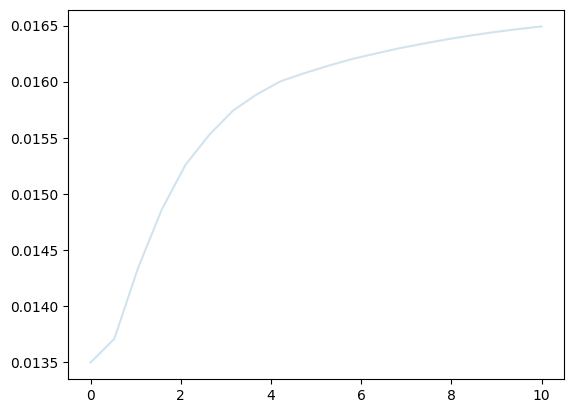

In [26]:
plt.plot(z_space, sigma8_z_error/sigma8_z, alpha=0.2)

In [27]:
F, F_marg, params, labels = forecast_derived()

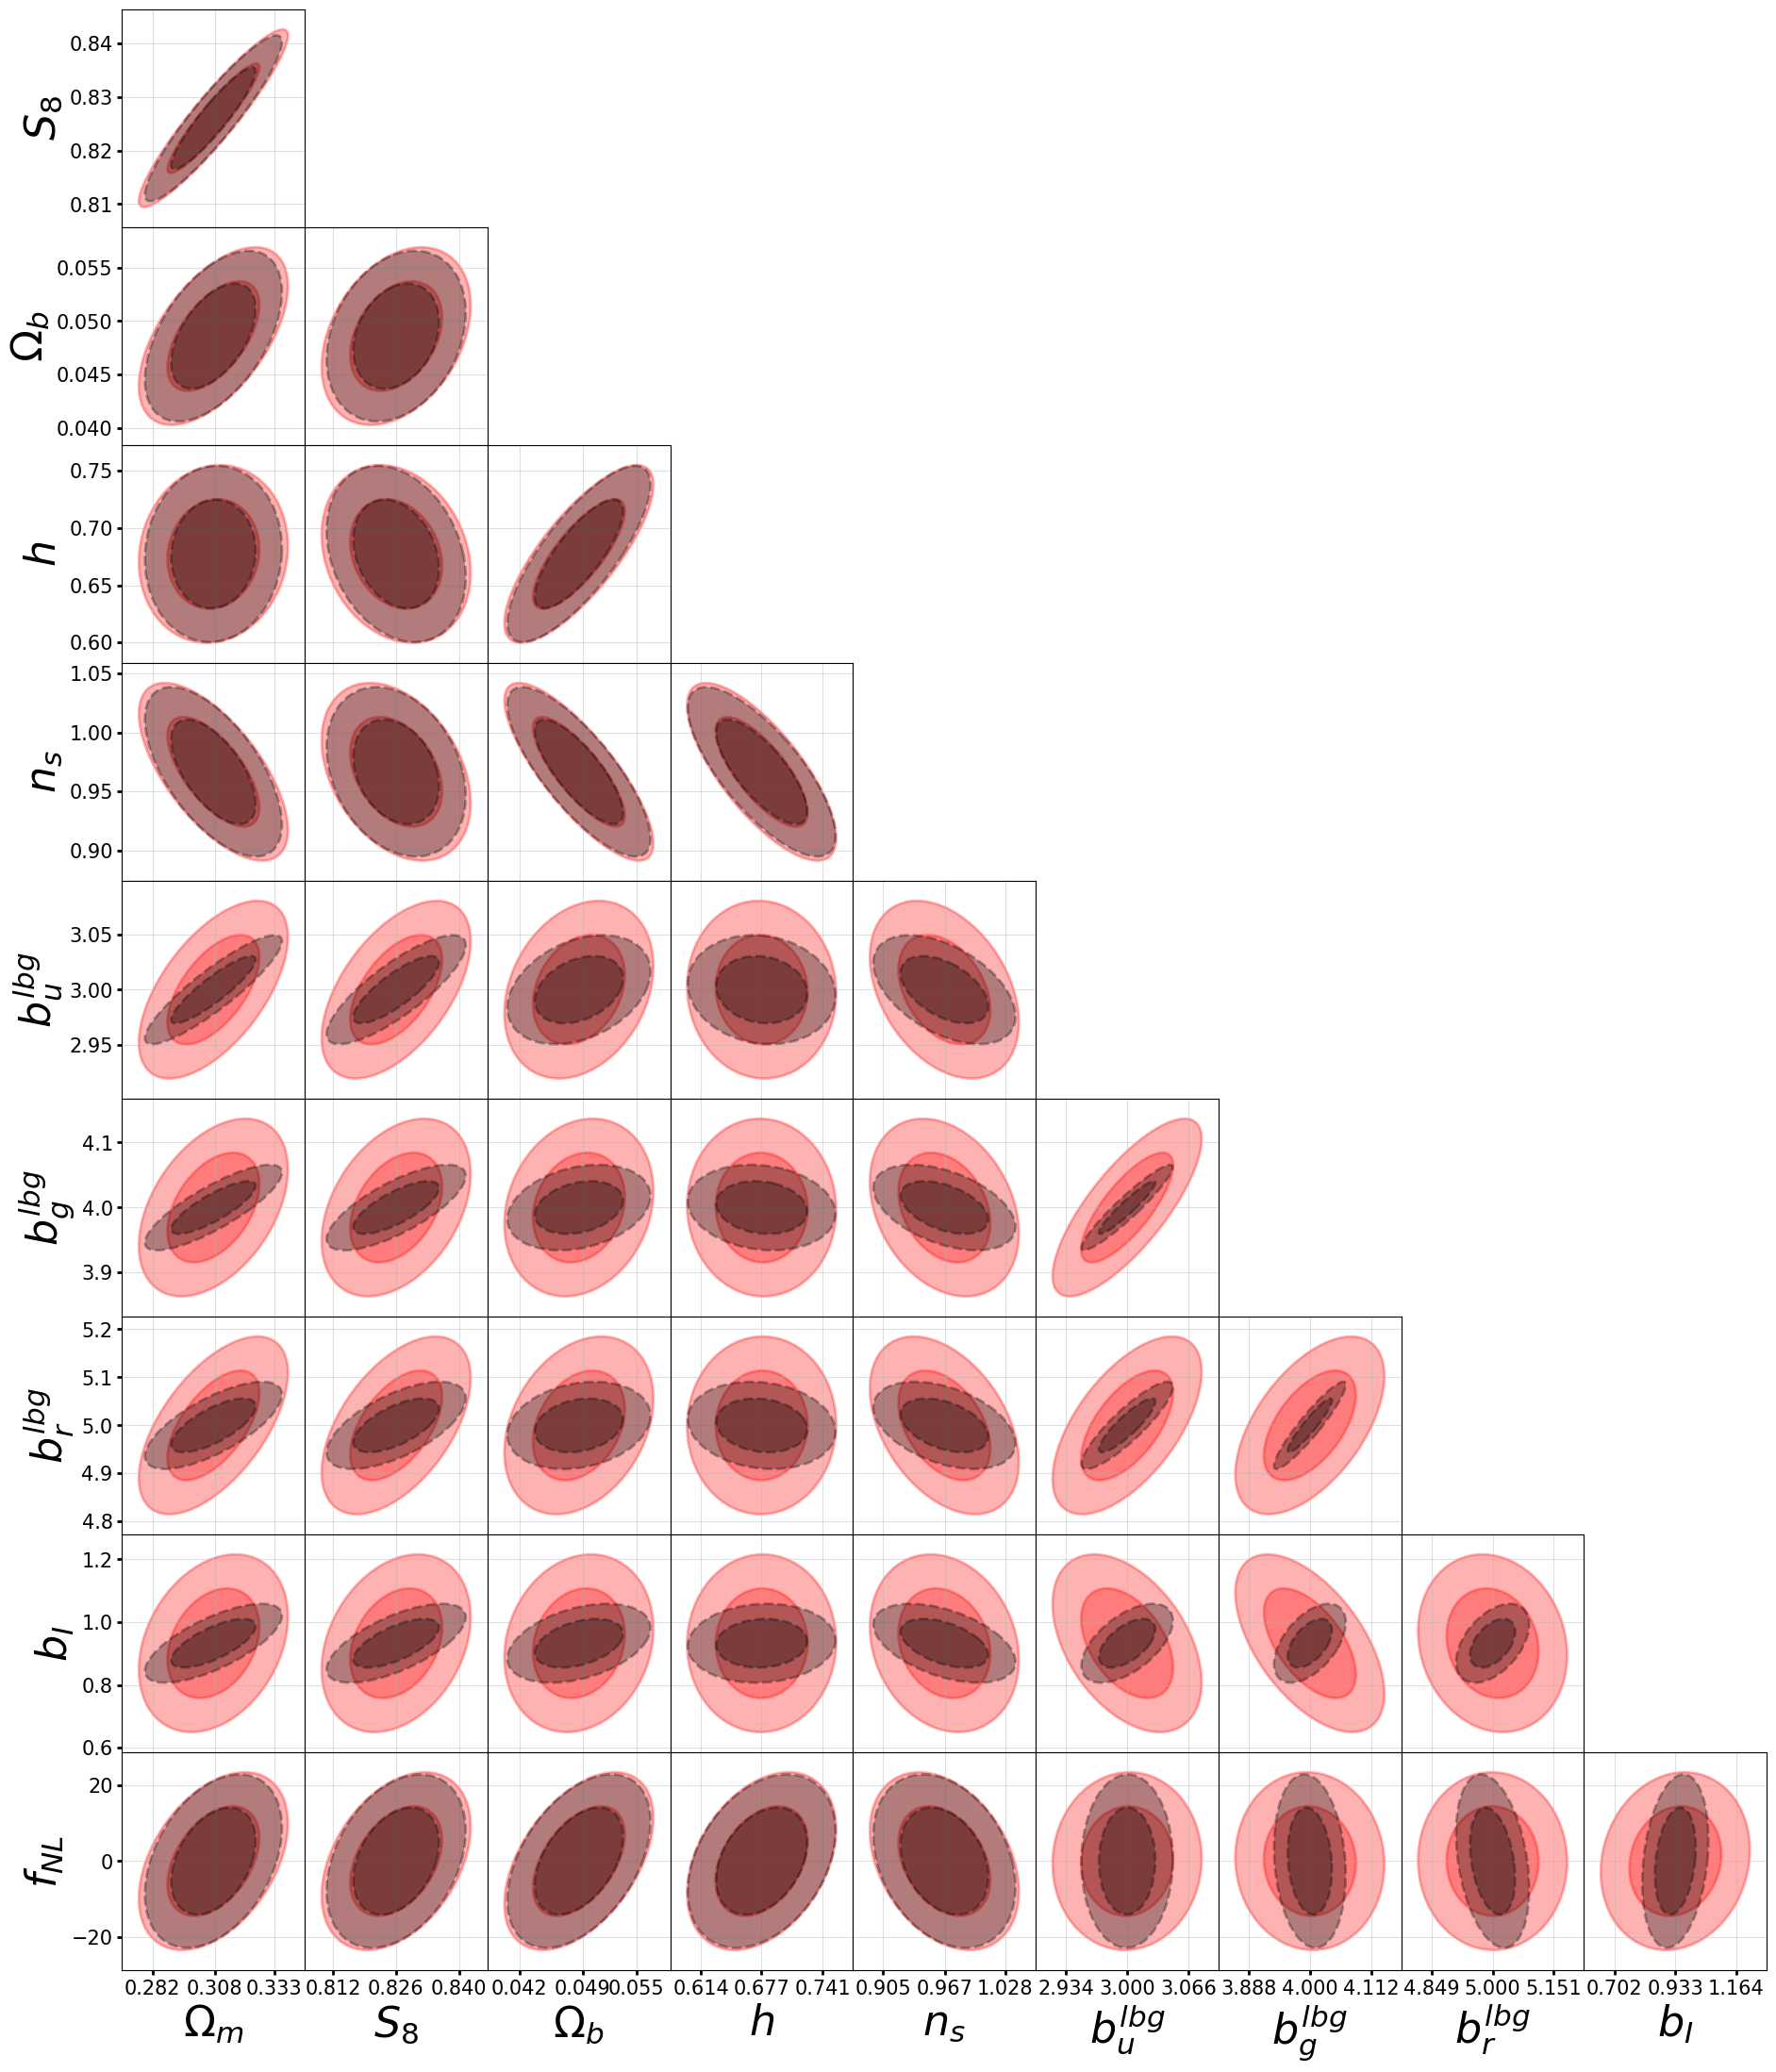

In [28]:
trig_plot(len(params), params, F, F_marg, F_extra=None, labels=labels)

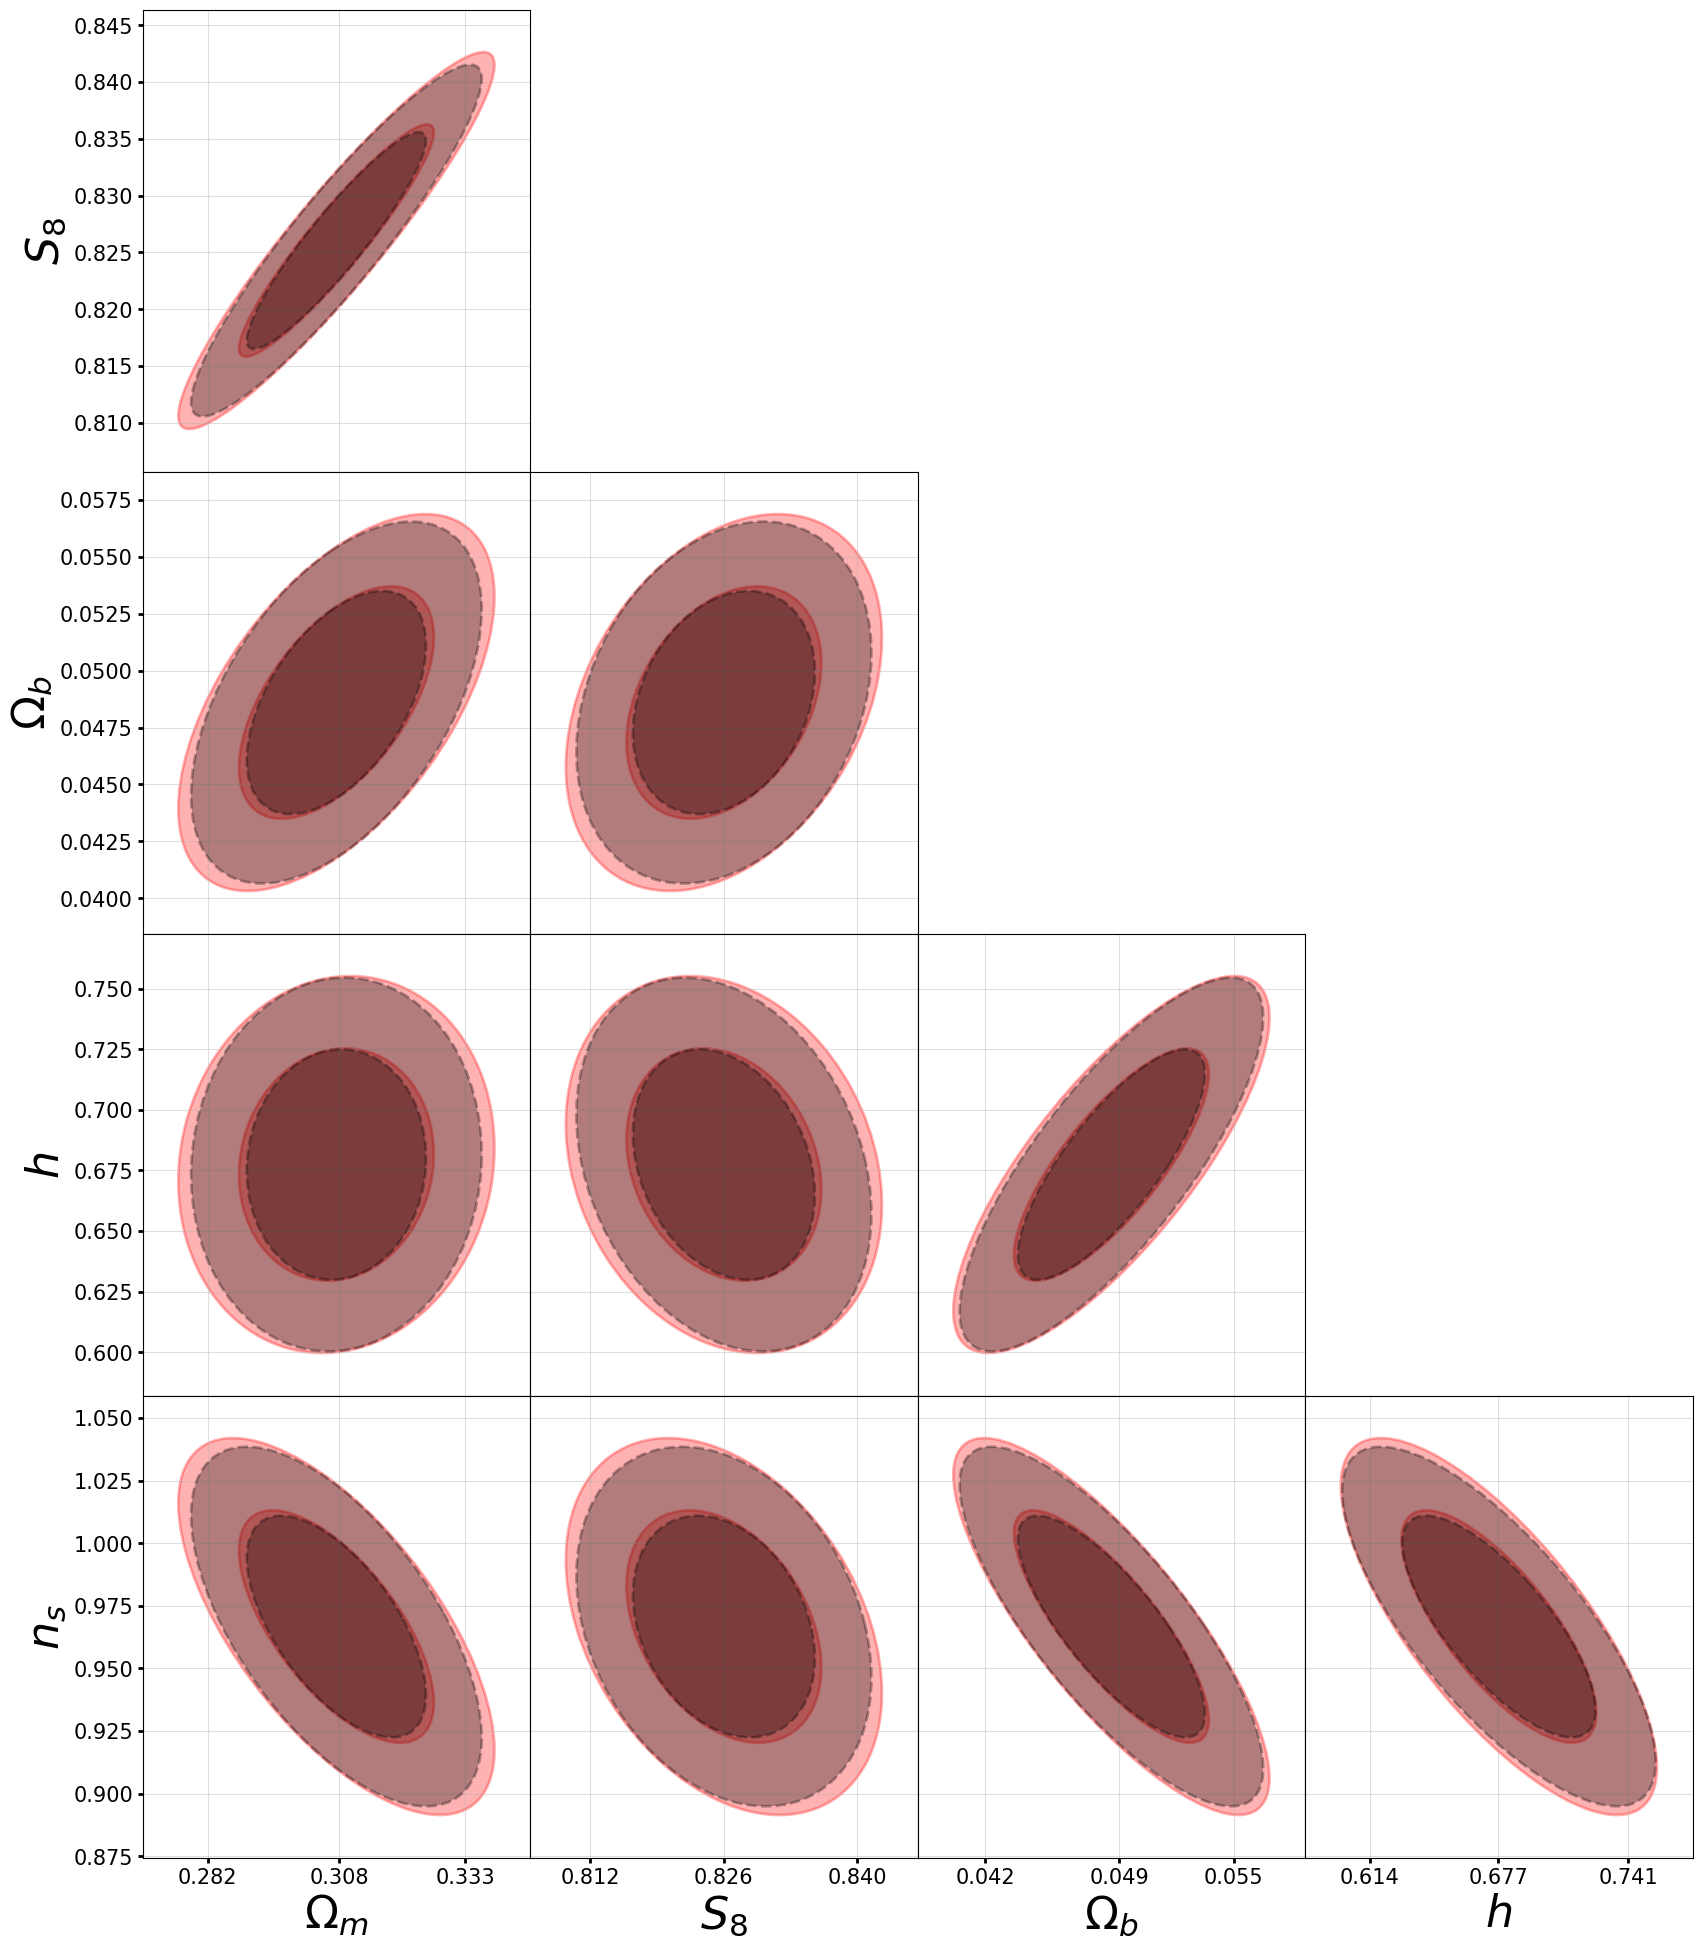

In [29]:
trig_plot(5, params, F, F_marg, F_extra=None, labels=labels)

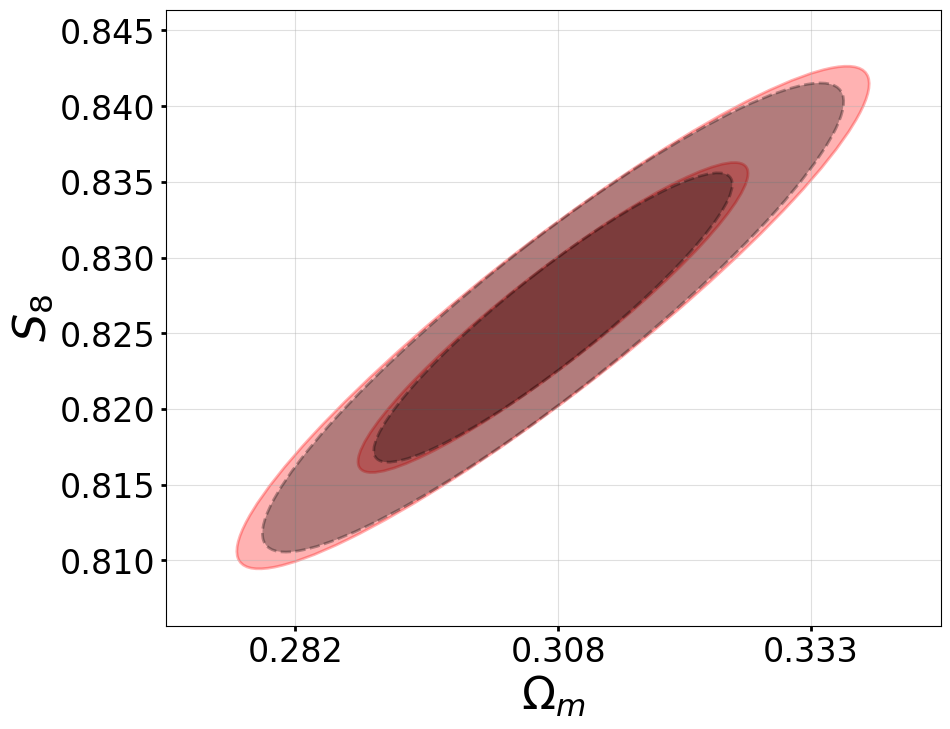

In [30]:
i = 1
j = 0
plt.figure(figsize=(10, 8))
plt.grid(alpha=0.4, zorder=-1)

utils.plot_contours(F, params, j, i, K=2.279, fill=True,color='k', alpha=0.3, zorder=5, ls="--", lw=2)
utils.plot_contours(F, params, j, i, K=5.991, fill=True,color='k',  alpha=0.3, zorder=5, ls="--", lw=2)

utils.plot_contours(F_marg, params, j, i, K=2.279, fill=True,color='r', alpha=0.3, zorder=1, lw=2)
utils.plot_contours(F_marg, params, j, i, K=5.991, fill=True,color='r', alpha=0.3, zorder=1, lw=2)

plt.ylabel(labels[i], fontsize = 32)
plt.xlabel(labels[j], fontsize = 32)

plt.tick_params(axis="x", width = 2, labelsize=24)
plt.tick_params(axis="y", width = 2, labelsize=24)

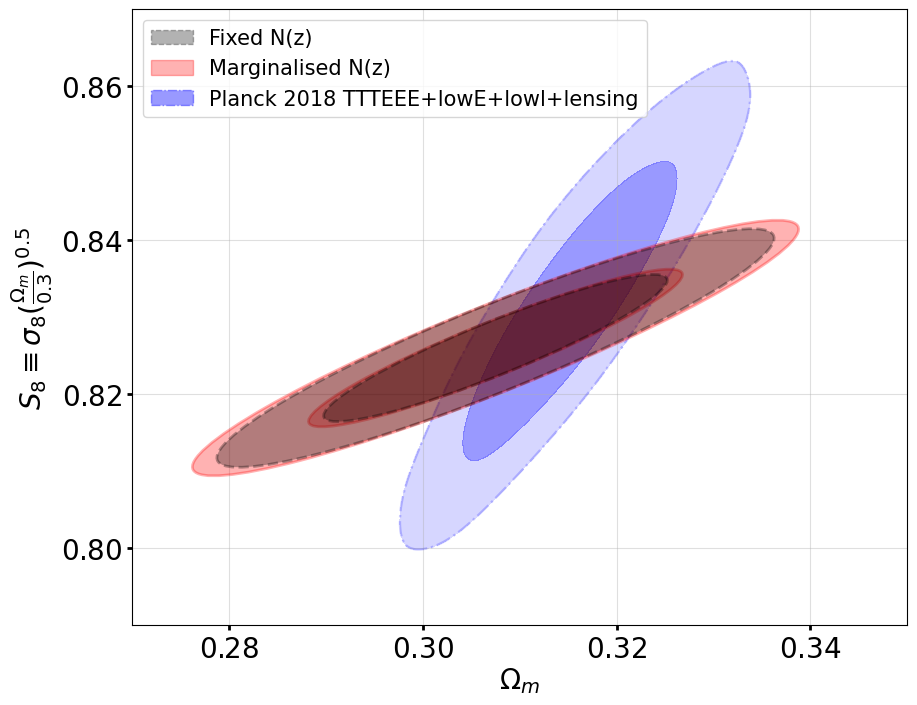

<Figure size 600x450 with 0 Axes>

In [31]:
from getdist import plots
from getdist import MCSamples

from matplotlib.patches import Patch
import os

legend_elements = [Patch(facecolor='k', edgecolor='k', label='Fixed N(z)', linestyle='--', alpha=0.3),
                   Patch(facecolor='r', edgecolor='r', label='Marginalised N(z)', linestyle='-', alpha=0.3),
                   Patch(facecolor='b', edgecolor='b', label='Planck 2018 TTTEEE+lowE+lowl+lensing',linestyle='-.', alpha=0.4)]

i = 1
j = 0
f, ax = plt.subplots(1, 1, figsize=(10, 8))

utils.plot_contours(F, params, j, i, K=2.279, fill=True,color='k', alpha=0.3, zorder=500, ls="--", lw=2, label='Fixed N(z)')
utils.plot_contours(F, params, j, i, K=5.991, fill=True,color='k',  alpha=0.3, zorder=500, ls="--", lw=2)

utils.plot_contours(F_marg, params, j, i, K=2.279, fill=True,color='r', alpha=0.3, zorder=100, ls='-', lw=2)
utils.plot_contours(F_marg, params, j, i, K=5.991, fill=True,color='r', alpha=0.3, zorder=100, ls='-', lw=2,  label='Marginalised')

# getdist's chain_grid.py rejoins its own glob results onto chain_dir, which
# silently doubles a relative chain_dir into a bogus nested path; an absolute
# path avoids that (os.path.join short-circuits on an absolute second arg).
g=plots.get_single_plotter(chain_dir=os.path.abspath('planck_data_full/base/plikHM_TTTEEE_lowl_lowE_lensing'))
roots = ['base_plikHM_TTTEEE_lowl_lowE_lensing']
pairs = ['omegam', 'S8']
g.plot_2d(roots, 'omegam', 'S8', filled=True, shaded=False, ax=ax, alphas=0.4, ls='-.', lws=1, colors=['blue'])

ax.grid(alpha=0.4, zorder=-100)

ax.set_xlim(0.27, 0.35)
ax.set_ylim(0.79, 0.87)

ax.set_ylabel('$S_{8} \equiv \sigma_{8}(\\frac{\Omega_{m}}{0.3})^{0.5}$', fontsize = 20)
ax.set_xlabel(labels[j], fontsize = 20)

ax.tick_params(axis="x", width = 2, labelsize=20)
ax.tick_params(axis="y", width = 2, labelsize=20)

ax.legend(handles=legend_elements, loc='upper left', fontsize=15)